Jo Bovy (Toronto) has written a book on galactic dynamics, https://galaxiesbook.org/, that
includes lots of integration with a python package (galpy) that he’s also written. Install
galpy and work through each of the code examples in section 7.3 of the book (“Gravitational
potentials from disk density distributions”), reproducing the figures and calculations. For
each of the examples, provide detailed documentation about what the code is doing, with
connections to the material in section 7.3 (or elsewhere).

## Section 7.3 "Gravitational potentials from disk density distributions" Examples
- 7.3.3.2. The razor-thin exponential disk
- 7.3.4.1. The double-exponential disk

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\RazorThinExponentialDiskPotential.py:103: RuntimeWarning: invalid value encountered in scalar multiply
  * (special.i0(y) * special.k0(y) - special.i1(y) * special.k1(y))

C:\Users\17135\AppData\Local\Temp\ipykernel_57772\1487760740.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return -self._cumulmassfunc(r)*R/r**3.



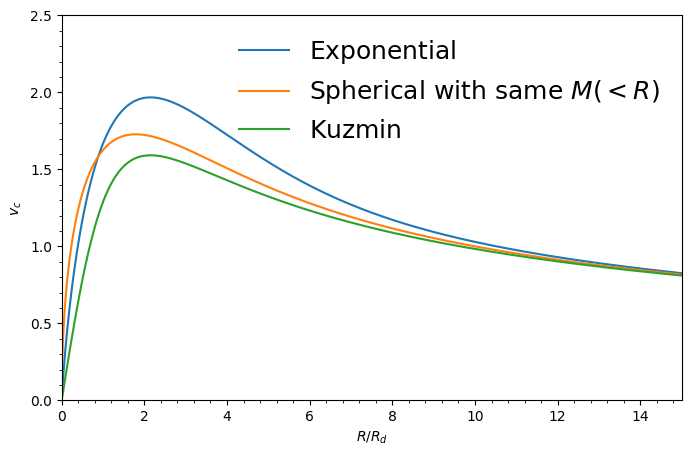

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import galpy as galpy
from galpy import potential

class EquivalentMassSphericalPotential(potential.Potential):
    def __init__(self,amp=1.,cumulmassfunc=None,ro=None,vo=None):
        potential.Potential.__init__(self,amp=amp,ro=ro,vo=vo)
        self._cumulmassfunc= cumulmassfunc
    def _Rforce(self,R,z,phi=0.,t=0.):
        r= np.sqrt(R**2.+z**2.)
        return -self._cumulmassfunc(r)*R/r**3.
plt.figure(figsize=(8,5))
Rd= 1.
kzp= potential.KuzminDiskPotential(amp=10.,a=2.15/np.sqrt(2.)*Rd)
rp= potential.RazorThinExponentialDiskPotential(amp=10./(2.*np.pi),hr=Rd)
rp_spher= EquivalentMassSphericalPotential(amp=10.,\
                cumulmassfunc=lambda R: Rd**2.-Rd*(R+Rd)*np.exp(-R/Rd))
line_rp= rp.plotRotcurve(Rrange=[0.,15.],\
                    label=r'$\mathrm{Exponential}$',yrange=[0.,2.5],
                    xlabel=r'$R/R_d$',ylabel=r'$v_c$',gcf=True)
line_rp_spher= rp_spher.plotRotcurve(Rrange=[0.,15.],\
                    label=r'$\mathrm{Spherical\ with\ same}\ M(<R)$',
                    overplot=True)
line_kuzmin= kzp.plotRotcurve(Rrange=[0.,15.],\
                    label=r'$\mathrm{Kuzmin}$',
                    overplot=True)
plt.legend(handles=[line_rp[0],line_rp_spher[0],line_kuzmin[0]],
       fontsize=18.,loc='upper right',frameon=False);



c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:224: RuntimeWarning: divide by zero encountered in scalar divide
  -4.0

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\g

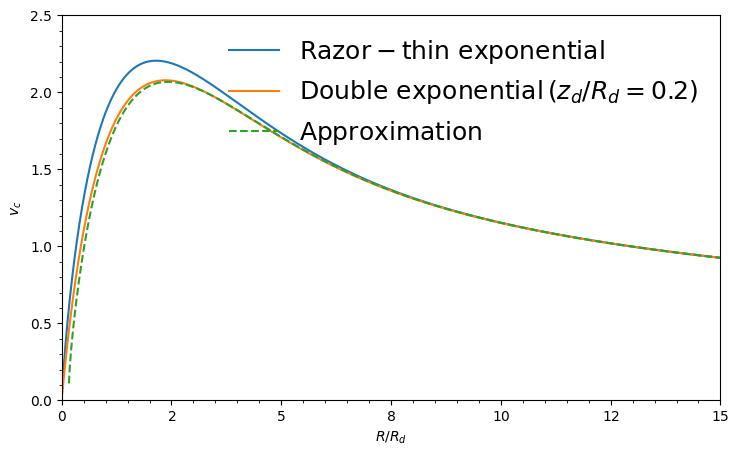

In [ ]:
from scipy import special
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8.5,5))
Rd= 0.2
zd= 0.2*0.2
rp= potential.RazorThinExponentialDiskPotential(amp=10.,hr=Rd)
dp= potential.DoubleExponentialDiskPotential(amp=10./2./zd,hr=Rd,hz=zd)
line_rp= rp.plotRotcurve(Rrange=[0.,3.],\
                    label=r'$\mathrm{Razor-thin\ exponential}$',
                    yrange=[0.,2.5],gcf=True,
                    xlabel=r'$R/R_d$',ylabel=r'$v_c$')
line_dp= dp.plotRotcurve(Rrange=[0.,3.],\
                    label=r'$\mathrm{Double\ exponential}\,(z_d/R_d = 0.2)$',
                    overplot=True)
# Also compute the approximation above
Rs= np.linspace(0.,3.,1001)
line_approx= plt.plot(Rs,np.sqrt(np.pi*rp._amp*Rs**2./Rd\
                  *(special.i0(Rs/2./Rd)*special.k0(Rs/2/Rd)
                      -special.i1(Rs/2/Rd)*special.k1(Rs/2./Rd))\
                    -2*np.pi*rp._amp*Rs*zd/Rd*np.exp(-Rs/Rd)),
                 label=r'$\mathrm{Approximation}$',ls='--')
# To get the ticklabels correct, need to multiply the labels
def perRd(x,pos):
    return r'$%.0f$' % (x*5.)
plt.gca().xaxis.set_major_formatter(FuncFormatter(perRd))
plt.legend(handles=[line_rp[0],line_dp[0],line_approx[0]],
       fontsize=12.,loc='upper right',frameon=False);



Then, use galpy to calculate the gravitational potential for the Milky Way (See the docu-
mentation). 

Start with “MWPotential2014” but also consider a total mass of the Milky Way
that is 2x larger. [Question - 2x larger component wise? Because outputs look the same]

For both masses, plot the individual potentials (bulge, disk, dark matter)
and the total potential (one plot for each mass). [Question - evaluate potentials and then plot 1D cut?]

Do the same for the circular velocity curve
Vcirc(r) in both cases. 

If we add a black hole of 4.3 × 106 M⊙ at the center, how far out in
radius will the affect the total circular velocity and total potential?

In [ ]:
from galpy.potential.mwpotentials import MWPotential2014

[<galpy.potential.PowerSphericalPotentialwCutoff.PowerSphericalPotentialwCutoff object at 0x000001C2FE7B4100>, <galpy.potential.MiyamotoNagaiPotential.MiyamotoNagaiPotential object at 0x000001C2FE7B4070>, <galpy.potential.TwoPowerSphericalPotential.NFWPotential object at 0x000001C2FE7B4160>]


<Figure size 700x600 with 0 Axes>

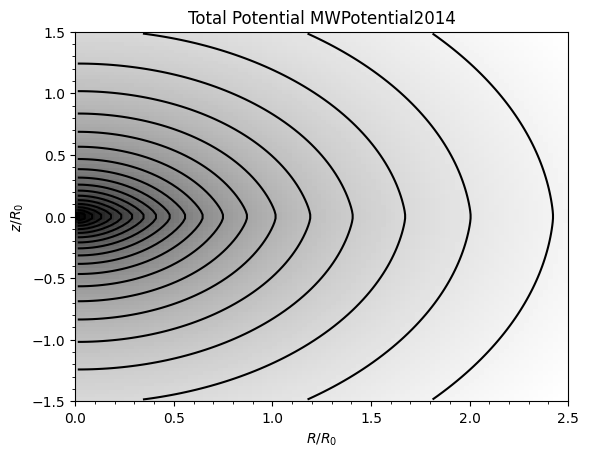

<Figure size 700x600 with 0 Axes>

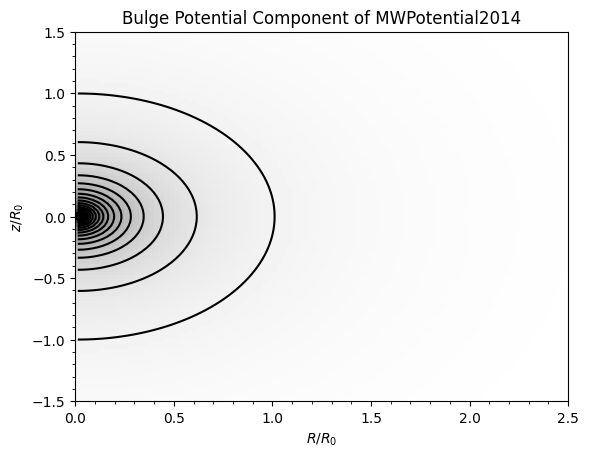

<Figure size 700x600 with 0 Axes>

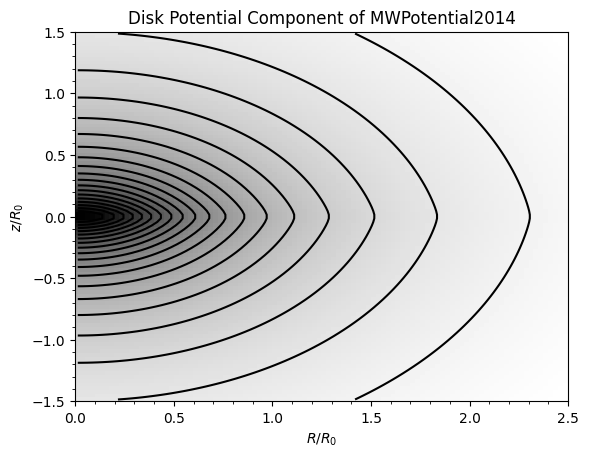

<Figure size 700x600 with 0 Axes>

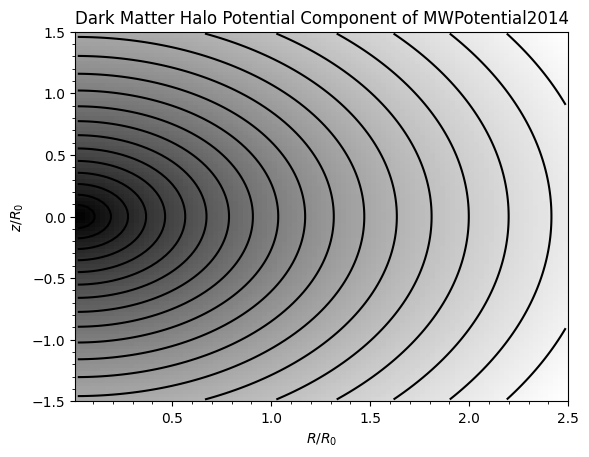

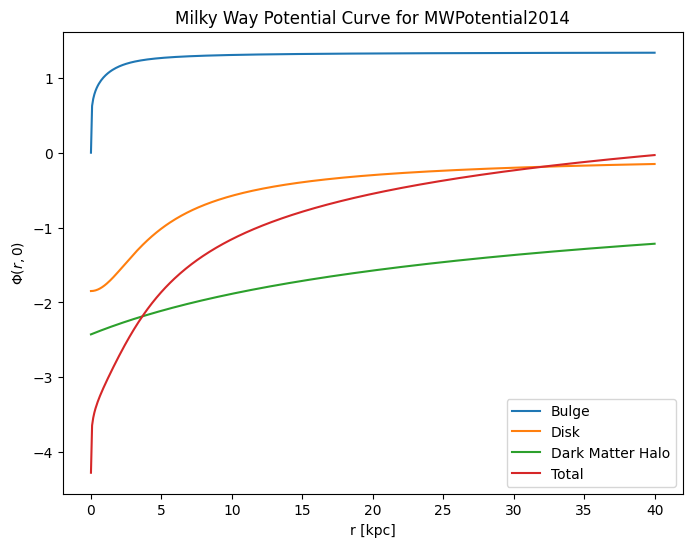

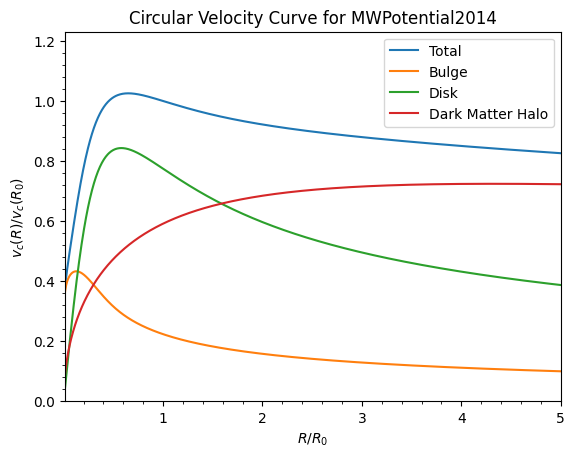

<Figure size 700x600 with 0 Axes>

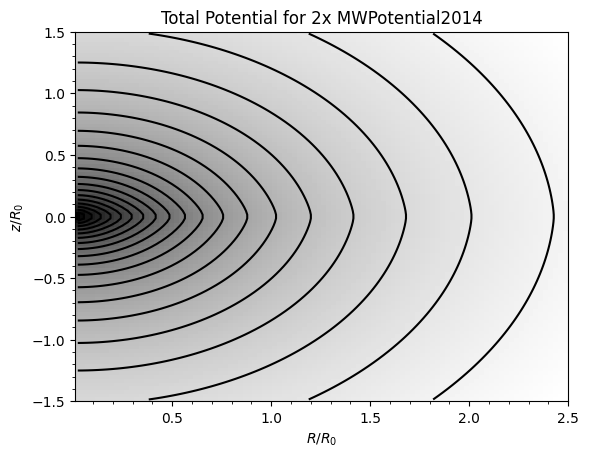

<Figure size 700x600 with 0 Axes>

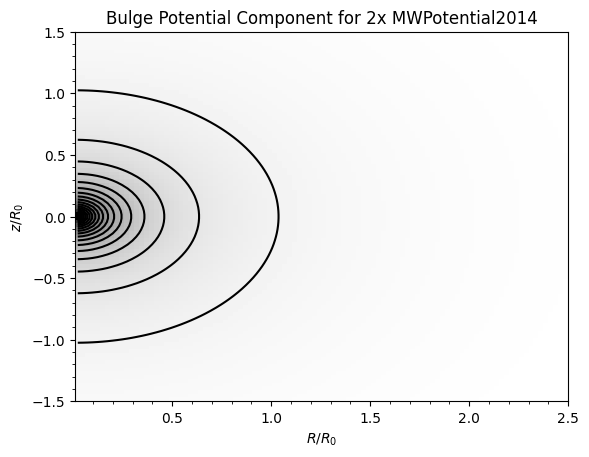

<Figure size 700x600 with 0 Axes>

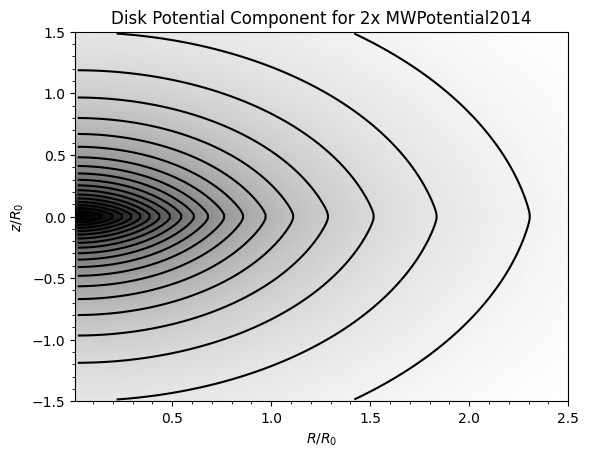

<Figure size 700x600 with 0 Axes>

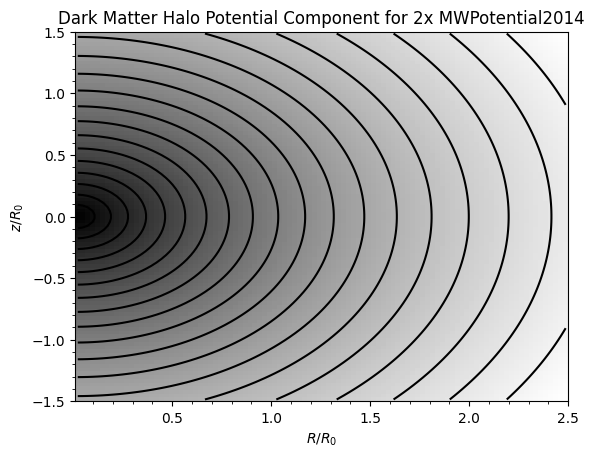

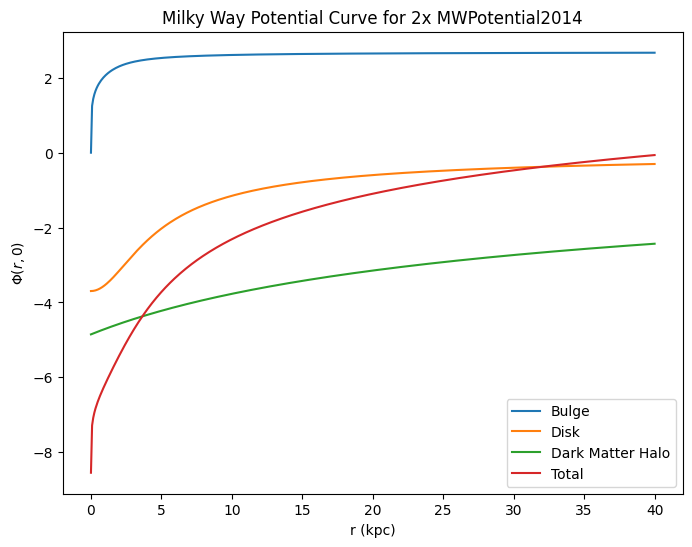

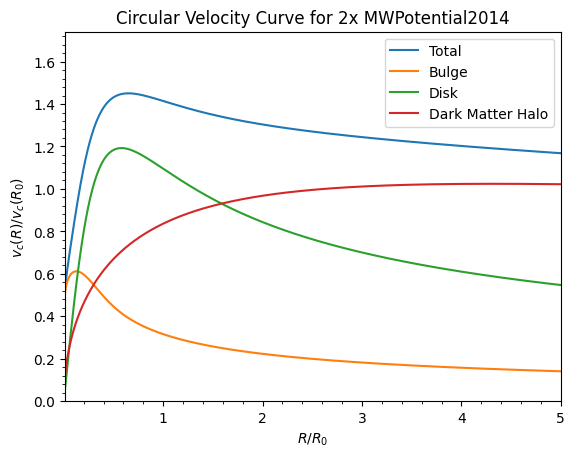

In [36]:
# Calculate gravitational potential for Milky Way using Mass 1 (“MWPotential2014”) and Mass 2 (total)
from galpy.potential import PowerSphericalPotentialwCutoff, MiyamotoNagaiPotential, NFWPotential
from galpy.potential import plotPotentials, plotRotcurve, evaluatePotentials
import numpy as np

bp= PowerSphericalPotentialwCutoff(alpha=1.8,rc=1.9/8.,normalize=0.05)
mp= MiyamotoNagaiPotential(a=3./8.,b=0.28/8.,normalize=.6)
nfwp= NFWPotential(a=16/8.,normalize=.35)
MWPotential2014= bp+mp+nfwp
# print(MWPotential2014) # this is the potential of the Milky Way

# Mass 1 plotting potential components 
rmax = 2.5
zmax = 1.5

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014, rmin=0.0, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Total Potential MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014[0], rmin=0.0, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Bulge Potential Component of MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014[1], rmin=0.0, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Disk Potential Component of MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014[2], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Dark Matter Halo Potential Component of MWPotential2014")

# Mass 1 plotting potentials after evaluating
r = np.linspace(0.0, 40.0, 500)
R = r / 8.0

potential_bulge_1 = []
potential_disk_1 = []
potential_dm_1 = []
potential_tot_1 = []

for r_i in R:
    potential_bulge_1.append(evaluatePotentials(MWPotential2014[0], r_i, 0.0))
    potential_disk_1.append(evaluatePotentials(MWPotential2014[1], r_i, 0.0))
    potential_dm_1.append(evaluatePotentials(MWPotential2014[2], r_i, 0.0))
    potential_tot_1.append(evaluatePotentials(MWPotential2014, r_i, 0.0))

plt.figure(figsize=(8,6))
plt.plot(r, potential_bulge_1, label='Bulge')
plt.plot(r, potential_disk_1, label='Disk')
plt.plot(r, potential_dm_1, label='Dark Matter Halo')
plt.plot(r, potential_tot_1, label='Total')
plt.xlabel('r [kpc]')
plt.ylabel(r'$\Phi(r,0)$')
plt.title('Milky Way Potential Curve for MWPotential2014')
plt.legend()
plt.show()

# Mass 1 Plotting Circular Velocity Curve

plotRotcurve(MWPotential2014, label='Total')
plotRotcurve(MWPotential2014[0], label='Bulge', overplot=True)
plotRotcurve(MWPotential2014[1], label='Disk',  overplot=True)
plotRotcurve(MWPotential2014[2], label='Dark Matter Halo',  overplot=True)
plt.title("Circular Velocity Curve for MWPotential2014")
plt.legend()


# Mass 2

MWPotential2014[0]*= 2 # bulge component
MWPotential2014[1]*= 2 # disk component
MWPotential2014[2]*= 2 # dark matter halo component

MWPotential_2x = MWPotential2014[0] + MWPotential2014[1] + MWPotential2014[2]

#print(MWPotential_2x) # this is the potential for the total mass of the Milky Way

# Mass 2 plotting potential components
plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x, rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Total Potential for 2x MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x[0], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Bulge Potential Component for 2x MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x[1], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Disk Potential Component for 2x MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x[2], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Dark Matter Halo Potential Component for 2x MWPotential2014")

# Mass 2 plotting potentials after evaluating
# same linspace as before
potential_bulge_2 = []
potential_disk_2 = []
potential_dm_2 = []
potential_tot_2 = []

for r_i in R:
    potential_bulge_2.append(evaluatePotentials(MWPotential_2x[0], r_i, 0.0))
    potential_disk_2.append(evaluatePotentials(MWPotential_2x[1], r_i, 0.0))
    potential_dm_2.append(evaluatePotentials(MWPotential_2x[2], r_i, 0.0))
    potential_tot_2.append(evaluatePotentials(MWPotential_2x, r_i, 0.0))

plt.figure(figsize=(8,6))
plt.plot(r, potential_bulge_2, label='Bulge')
plt.plot(r, potential_disk_2, label='Disk')
plt.plot(r, potential_dm_2, label='Dark Matter Halo')
plt.plot(r, potential_tot_2, label='Total')
plt.xlabel('r (kpc)')
plt.ylabel(r'$\Phi(r,0)$')
plt.title('Milky Way Potential Curve for 2x MWPotential2014')
plt.legend()
plt.show()

# Mass 2 Circular Velocity Curve

plotRotcurve(MWPotential_2x, label='Total')
plotRotcurve(MWPotential_2x[0], label='Bulge', overplot=True)
plotRotcurve(MWPotential_2x[1], label='Disk',  overplot=True)
plotRotcurve(MWPotential_2x[2], label='Dark Matter Halo',  overplot=True)
plt.title("Circular Velocity Curve for 2x MWPotential2014")
plt.legend()


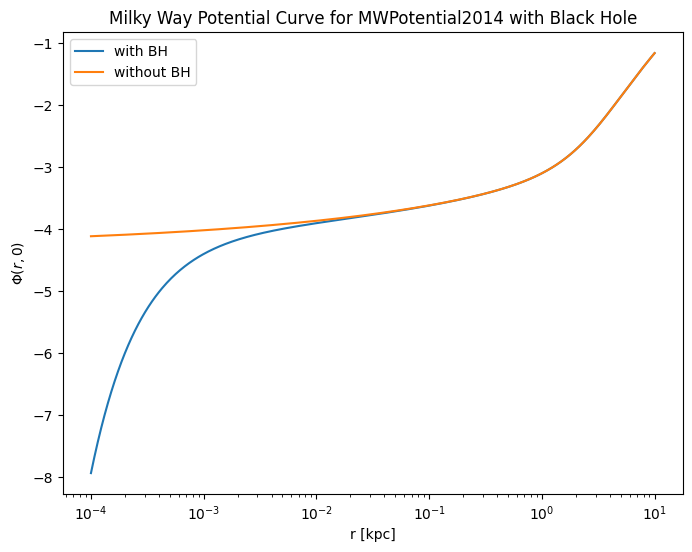

<Figure size 800x600 with 0 Axes>

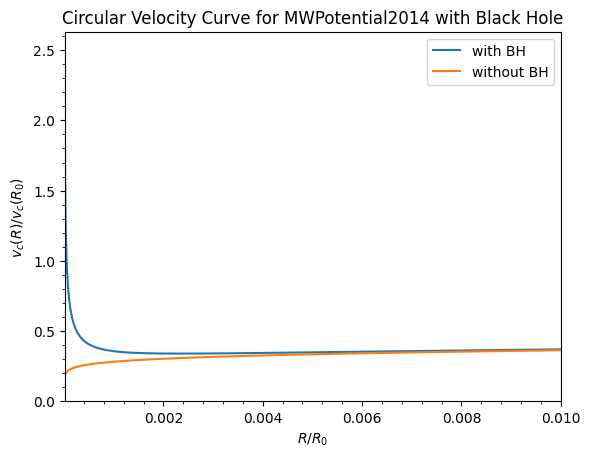

In [47]:
# adding black hole to the center of Milky Way
from galpy.potential import PowerSphericalPotentialwCutoff, MiyamotoNagaiPotential, NFWPotential
from galpy.potential import plotPotentials, plotRotcurve, evaluatePotentials
from galpy.potential import KeplerPotential
from galpy.util import conversion
import numpy as np

bp= PowerSphericalPotentialwCutoff(alpha=1.8,rc=1.9/8.,normalize=0.05)
mp= MiyamotoNagaiPotential(a=3./8.,b=0.28/8.,normalize=.6)
nfwp= NFWPotential(a=16/8.,normalize=.35)
MWPotential2014= bp+mp+nfwp

MWPotential2014wBH = MWPotential2014+KeplerPotential(amp=4.3*10**6./conversion.mass_in_msol(220.,8.))

# potential
r = np.logspace(-4, 1, 500)
R = r / 8.0

potential_tot_1_BH = []
potential_tot_1 = []

for r_i in R:
    potential_tot_1_BH.append(evaluatePotentials(MWPotential2014wBH, r_i, 0.0))
    potential_tot_1.append(evaluatePotentials(MWPotential2014, r_i, 0.0))

plt.figure(figsize=(8,6))
plt.semilogx(r, potential_tot_1_BH, label='with BH')
plt.semilogx(r, potential_tot_1, label='without BH')
plt.xlabel('r [kpc]')
plt.ylabel(r'$\Phi(r,0)$')
plt.title('Milky Way Potential Curve for MWPotential2014 with Black Hole')
plt.legend()
plt.show()

# Circular Velocity Curve

plt.figure(figsize=(8,6))
plotRotcurve(MWPotential2014wBH, Rrange=[1e-5, 0.01], label='with BH')
plotRotcurve(MWPotential2014, Rrange=[1e-5, 0.01], overplot=True, label = 'without BH')
plt.title("Circular Velocity Curve for MWPotential2014 with Black Hole")
plt.legend()


If we add a black hole to the center of the Milky Way, the impact on the circular velocity curve and total potential is limited to the inner part of the galaxy at small radii away from the center. As we get further away from the center of the galaxy, these quantities are not altered in any significant manner. The black hole will appreciably effect the total potential and circular velocity up to the radius from the center of the galaxy being on the order of tens of parsecs, after which the contribution becomes moot.